<hr/>
<b>Nombre</b>: Mateo Bustamante Moreno
<br/>
<b>Cédula</b>: 1001228880


## Enunciado

**Objetivo**: El objetivo de este proyecto es poner a prueba la idea de que es posible simular un  sistema de N-cuerpos jerarquicos usando un *árbol* de sistemas de 2 cuerpos.

En particular compararemos la predicción de las posiciones que para un sistema múltiple de estrellas nos da la simulación con un sistema jerárquico y el mismo resultado pero calculado como si el sistema fuera un sistema de N cuerpos completo.

**Procedimiento**:

El sistema que simularemos es el de un sistema binario formado por dos estrellas "s" y "e".  Alrededor de la estrella "e" gira un planeta "p", a cuyo alrededor, a su vez, gira una luna "L".  Los datos de los cuerpos, dados en unidades canónicas, en las que $U_M = 80$ M$_{\rm Jup}$, $U_L = 0.01$ au, son.

- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.

- Condiciones iniciales (las posiciones están dadas respecto al cuerpo más masivo de cada subsistema):

   - Sistema p-L:
     - Posición inicial de p : r = [0,0,0]
     - Velocidad inicial de p: v = [0,0,0]
     - Posición inicial de L: r = [0.03,0,0]
     - Velocidad inicial de L: v = [0,0.4,0.1]

   - Sistema e-pL (baricentro de p y L):
     - Posición inicial de e : r = [0,0,0]
     - Velocidad inicial de e: v = [0,0,0]
     - Posición inicial de pL: r = [0,0.4,0]
     - Velocidad inicial de pL: v = [0.9,0,0.2]
     
  - Sistema s-epL (baricentro e y pL):
     - Posición inicial de s : r = [0,0,0]
     - Velocidad inicial de s: v = [0,0,0]
     - Posición inicial de epL: r = [2,3,0]
     - Velocidad inicial de epL: v = [-0.2,0.7,0]



Una vez definidas las condiciones iniciales:

1. Dibujar el árbol del sistema jerárquico.

2. Simular usando `ncuerpos_solucion` cada subsistema por separado y obtener el vector y la velocidad relativa como función del tiempo de cada subsistema. Para el tiempo total de simulación encuentre el período orbital de cada subsistema ¿cuánto es?. El tiempo de la simulación será igual al período más largo.

3. Suponiendo que el centro de masa de todo el sistema está en reposo en el origen, calcular a partir la solución al problema relativo de cada subsistema, la posición de cada cuerpo en el tiempo.

4. Haga gráficos de las posiciones y una animación que muestre la trayectoria de las partículas.

5. Tomando las posiciones iniciales calculadas en 3, use otra vez `ncuerpos_solucion` para encontrar las posiciones y velocidades de todas las partículas respecto del centro de masa. Haga un gráfico de la solución obtenida y cálcule con el obtenido en 4. ¿Se ven parecidas?

6. Haga gráficos de las componentes x, y, z de la posición de cada partícula del sistema a lo largo del tiempo, calculadas con la aproximación jerárquica (punto 3) y con la solución al sistema completo (punto 5). Un gráfico por cuerpo. Comente su resultado.

7. Haga gráficos de la energía cinética total, la energía potencial total y la energía mecánica total como función del tiempo usando los resultados en 3. El gráfico debe expresarse en unidades más convencionales: en el eje x el tiempo en días,  en el eje y la energía en Joules. ¿Qué observa?

## Solución


###Nota: Para ver las animaciones es necesario correr el código.

#PUNTO 1

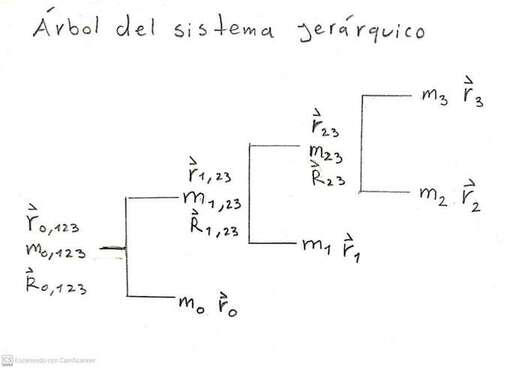

- La partícula $0$ es la estrella s, la de mayor masa.
- La partícula $1$ es la estrella e.
- La partícula $2$ es el planeta.
- La partícula $3$ es la luna.

#PUNTO 2

In [ ]:
!pip install -q pymcel

In [ ]:
!pip install -q celluloid

In [ ]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from mpl_toolkits.mplot3d import Axes3D
from astropy import constants


### - Definimos nuestro primer subsistema, el formado por 2 y 3, planeta y luna respectivamente, con sus masas, posiciones y velocidades

### - El tiempo de simulación (ts) se halló por tanteo, es de aproximadamente 60 unidades canónicas, y es dado por el periodo orbital del subsistema s-epl

In [ ]:
#Planeta
m2 = 0.01
r2 = [0,0,0]
v2 = [0,0,0]


#Luna
m3 = 0.001
r3 = [0.03,0,0]
v3 = [0,0.4,0.1]


sistema23 = [
    dict(m=m2,r=r2,v=v2),
    dict(m=m3,r=r3,v=v3),
]

ts = np.linspace(0,60,200)

In [ ]:
rs,vs,rps,vps,cuadraturas = pc.ncuerpos_solucion(sistema23,ts)

#Vector relativo entre 2 y 3
rs23 = rps[0,:,:] - rps[1,:,:]


#Velocidades relativas entre 2 y 3
vs23 = vps[0,:,:] - vps[1,:,:]

### - Definimos nuestro segundo subsistema, el formado por 1 y el subsistema 23, subsistema e-PL, con sus masas, posiciones y velocidades.

In [ ]:
##Estrella e
m1 = 0.5
r1 = [0,0,0]
v1 = [0,0,0]


##Subsistema PL
m23 = m2+m3
r23 = [0,0.4,0]
v23 = [0.9,0,0.2]

sistema1_23 = [
    dict(m=m1,r=r1,v=v1),
    dict(m=m23,r=r23,v=v23),
]

In [ ]:
rs,vs,rps,vps,cuadraturas = pc.ncuerpos_solucion(sistema1_23,ts)

#Vector relativo entre 1 y 23
rs1_23 = rps[0,:,:] - rps[1,:,:]


#Velocidades relativas entre 1 y 23
vs1_23 = vps[0,:,:] - vps[1,:,:]

### - Definimos nuestro tercer y último subsistema, el formado por 0 y el subsistema 123, subsistema s-ePL, con sus masas, posiciones y velocidades.

In [ ]:
#estrella s
m0 = 1
r0 = [0,0,0]
v0 = [0,0,0]


#Subsistema ePL
m123 = m1+m2+m3
r123 = [2,3,0]
v123 = [-0.2,0.7,0]

sistema0_123 = [
    dict(m=m0,r=r0,v=v0),
    dict(m=m123,r=r123,v=v123),
]

In [ ]:
rs,vs,rps,vps,cuadraturas = pc.ncuerpos_solucion(sistema0_123,ts)


#Vector relativo entre 0 y 123
rs0_123 = rps[0,:,:] - rps[1,:,:]


#Velocidades relativas entre 0 y 123
vs0_123 = vps[0,:,:] - vps[1,:,:]


#PUNTO 3

Recordemos qué:

- La partícula $0$ es la estrella s, la de mayor masa.
- La partícula $1$ es la estrella e.
- La partícula $2$ es el planeta.
- La partícula $3$ es la luna.


In [ ]:

#Centro de masa en el origen y en reposo del sistema 0-123
R0_123 = np.zeros((200,3))

#posición de la partícula 0
r0_t = R0_123 + (m1+m2+m3)/(m0+m1+m2+m3)*rs0_123

#centro de masa del sistema 1-23
R1_23 = R0_123 - m0/(m0+m1+m2+m3)*rs0_123



#Posición de la partícula 1
r1_t= R1_23 + (m2+m3)/(m1+m2+m3)*rs1_23

#Centro de masa del sistema 23
R23 = R1_23 - m1/(m1+m2+m3)*rs1_23


#Posición de la partícula 2
r2_t = R23 + m3/(m2+m3)*rs23

#posición de la partícula 3
r3_t = R23 - m2/(m2+m3)*rs23

#PUNTO 4

### - Gráfico de las posiciones de cada partícula en el tiempo

(-5.317519051243396, 3.158513560560453, -2.8653947903589634, 5.610637821444885)

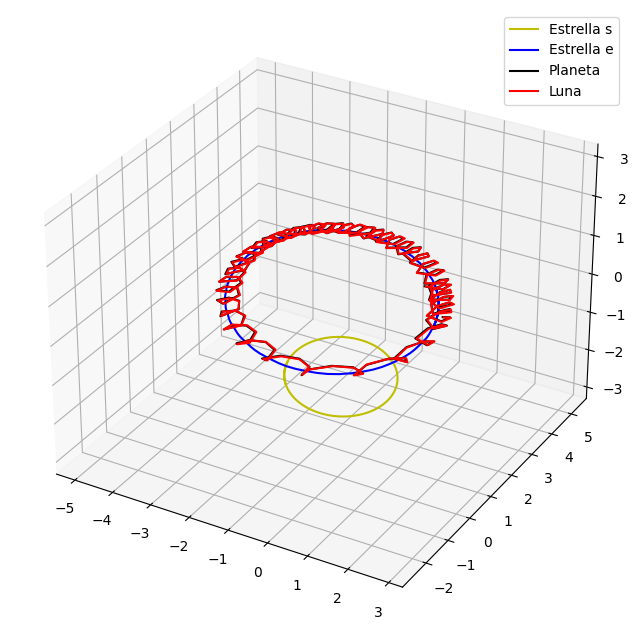

In [ ]:

plt.figure(figsize=(8,8))
ax = plt.axes(projection="3d")

fg = ax.plot(r0_t[:,0],r0_t[:,1],r0_t[:,2], c="y",label="Estrella s")
fg = ax.plot(r1_t[:,0],r1_t[:,1],r1_t[:,2], c="b",label="Estrella e")
fg = ax.plot(r2_t[:,0],r2_t[:,1],r2_t[:,2], c="k",label="Planeta")
fg = ax.plot(r3_t[:,0],r3_t[:,1],r3_t[:,2], c="r",label="Luna")

plt.legend()
plt.axis("equal")

### - Creamos la simulación de todo el sistema haciendo uso de celluloid

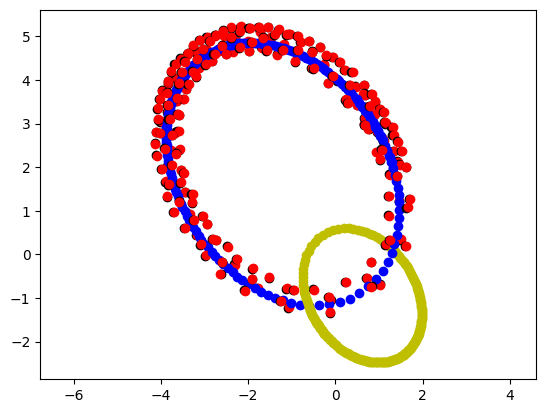

In [ ]:

figura = plt.figure()

c = Camera(figura)
plt.axis("equal")

for i in range(200):
  plt.plot(r0_t[i,0],r0_t[i,1],'yo')
  plt.plot(r1_t[i,0],r1_t[i,1],'bo')
  plt.plot(r2_t[i,0],r2_t[i,1],'ko')
  plt.plot(r3_t[i,0],r3_t[i,1],'ro')


  c.snap()

In [ ]:
anim = c.animate()
from IPython.display import HTML
HTML(anim.to_html5_video())

### - Reproduciremos la anterior animación pero en 3d

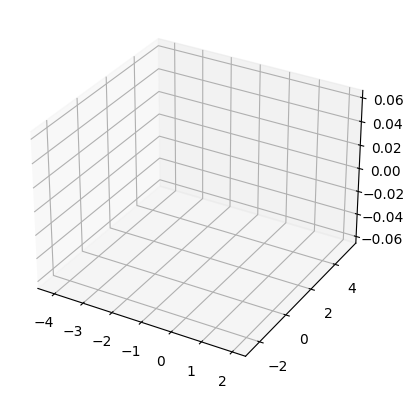

In [ ]:

fig = plt.figure()
camera = Camera(fig)
ax = fig.add_subplot(111, projection='3d')

for i in range(200):

  ax.plot3D(r0_t[i,0],r0_t[i,1],r0_t[i,2],"yo")
  ax.plot3D(r1_t[i,0],r1_t[i,1],r1_t[i,2],"bo")
  ax.plot3D(r2_t[i,0],r2_t[i,1],r2_t[i,2],"ko")
  ax.plot3D(r3_t[i,0],r3_t[i,1],r3_t[i,2],"ro")

  camera.snap()


animation = camera.animate()
HTML(animation.to_html5_video())

#PUNTO 5


###En el punto 3 hallamos las posiciones en el tiempo de cada cuerpo por medio del sistema jerárquico, ahora hallaremos las respectivas velocidades

In [ ]:

#Velocidad del centro de masa del sistema 0-123
vR0_123 = np.zeros((200,3))

#Velocidad de la partícula 0
vr0_t = vR0_123 + (m1+m2+m3)/(m0+m1+m2+m3)*vs0_123

#Velocidad del centro de masa del sistema 1-23
vR1_23 = vR0_123 - m0/(m0+m1+m2+m3)*vs0_123



#Velocidad de la partícula 1
vr1_t= vR1_23 + (m2+m3)/(m1+m2+m3)*vs1_23

#Velocidad del centro de masa del sistema 23
vR23 = vR1_23 - m1/(m1+m2+m3)*vs1_23



#Velocidad de la partícula 2
vr2_t = vR23 + m3/(m2+m3)*vs23

#Velociadad de la partícula 3
vr3_t = vR23 - m2/(m2+m3)*vs23



###Ahora usaremos las posiciones y velocidades iniciales de cada cuerpo y resolveremos todo el sistema usando ncuerpos_solución

In [ ]:

## El [0] es porque solo estamos tomando las posiciones y velocidades iniciales
sistema_total=[
    dict(m=m0,r=r0_t[0],v=vr0_t[0]),
    dict(m=m1,r=r1_t[0],v=vr1_t[0]),
    dict(m=m2,r=r2_t[0],v=vr2_t[0]),
    dict(m=m3,r=r3_t[0],v=vr3_t[0]),
]


In [ ]:
rs,vs,rps,vps,cuadraturas = pc.ncuerpos_solucion(sistema_total,ts)

### Gráfico 3d de las órbitas de los cuerpos en el tiempo, el sistema fue resuelto como un todo por ncuerpos_solución, solo con las masas, posiciones y velocidades iniciales.


(-5.320858810740569, 3.168395060532079, -2.8656107704138707, 5.623643100858778)

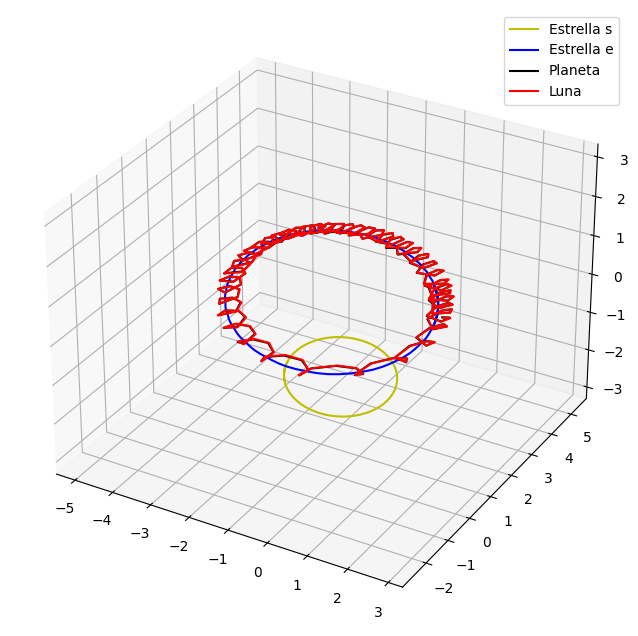

In [ ]:
plt.figure(figsize=(8,8))
ax = plt.axes(projection="3d")

fg = ax.plot(rps[0,:,0],rps[0,:,1],rps[0,:,2], c="y",label="Estrella s")
fg = ax.plot(rps[1,:,0],rps[1,:,1],rps[1,:,2], c="b",label="Estrella e")
fg = ax.plot(rps[2,:,0],rps[2,:,1],rps[2,:,2], c="k",label="Planeta")
fg = ax.plot(rps[3,:,0],rps[3,:,1],rps[3,:,2], c="r",label="Luna")

plt.legend()
plt.axis("equal")

### Gráfico similar al anterior pero en 2d

(-4.43993032186293, 2.28746657165444, -2.8656107704138707, 5.623643100858778)

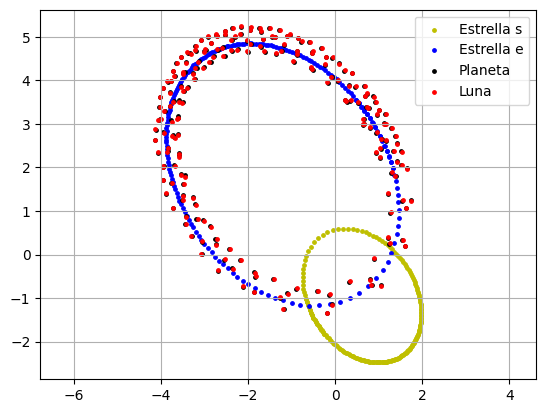

In [ ]:
plt.figure()
plt.scatter(rps[0,:,0],rps[0,:,1],s=6, c="y",label="Estrella s")
plt.scatter(rps[1,:,0],rps[1,:,1],s=6, c="b",label="Estrella e")
plt.scatter(rps[2,:,0],rps[2,:,1],s=6, c="k",label="Planeta")
plt.scatter(rps[3,:,0],rps[3,:,1],s=6, c="r",label="Luna")
plt.grid()

plt.legend()
plt.axis('equal')

####En los puntos anteriores realizamos diferentes gráficas, en el punto 4 se hizo un gráfico de las posiciones de los cuerpos en el tiempo halladas por un sistema jerárquico de dos cuerpos, y en el punto 5 se hizo algo similar pero resolviendo el sistema como un todo numericamente, usando ncuerpos_solución. A simple vista es imperceptible una diferencia entre los dos métodos, en el punto 6 se analizará con más detalle cada componente, pero es posible decir que gráficamente hay una muy buena aproximación, y como un sistema de n-cuerpos puede ser modelado con un sistema de pares jerárquico

#PUNTO 6

### Gráficos de las componentes de las partículas en el tiempo, con la aproximación jerárquica y la solución del sistema completo numericamente.

- Partícula $0$

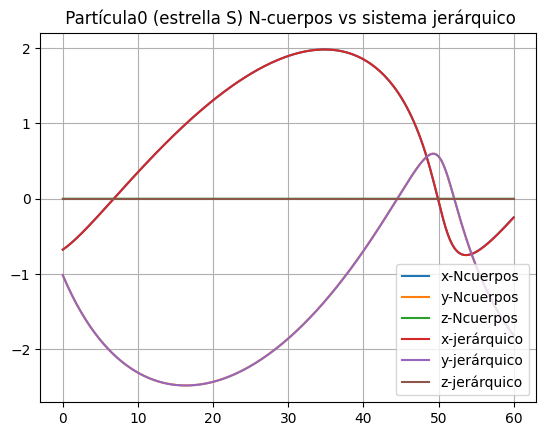

In [ ]:
##Partícula 0

plt.title(" Partícula 0 (estrella S) N-cuerpos vs sistema jerárquico")

plt.plot(ts,rs[0,:,0],label="x-Ncuerpos")
plt.plot(ts,rs[0,:,1],label="y-Ncuerpos")
plt.plot(ts,rs[0,:,2],label="z-Ncuerpos")

plt.plot(ts,r0_t[:,0],label="x-jerárquico")
plt.plot(ts,r0_t[:,1],label="y-jerárquico")
plt.plot(ts,r0_t[:,2],label="z-jerárquico")

plt.grid()
plt.legend()

A simple vista es muy dificil encontrar una diferencia, por esto procederemos a encontrar el error relativo porcentual entre los métodos, tomaremos los promedios y la solución númerica será el valor real o esperado. solo para darnos una pequeña idea de la diferencia que pueda existir entre los métodos

Más que un error es para ver si hay alguna diferencia, ya que no se calculará un error en si, hallaremos el promedio de cada componente y las sumaremos (promedio_en_x + promedio_en_y + promedio_en_z), esto para cada método y comparamos el resultado final.

In [ ]:
#### diferencia entre métodos Para la partícula 0



#valor esperado (la solución numérica)
Val_real = rs[0,:,0].mean() + rs[0,:,1].mean() + rs[0,:,2].mean()

#Valor medido (solución jerárquica)
Val_med = r0_t[:,0].mean() + r0_t[:,1].mean() + r0_t[:,2].mean()


print(abs((Val_real - Val_med)/Val_real)*100,"%")

0.06129106173160402 %


- Partícula 1

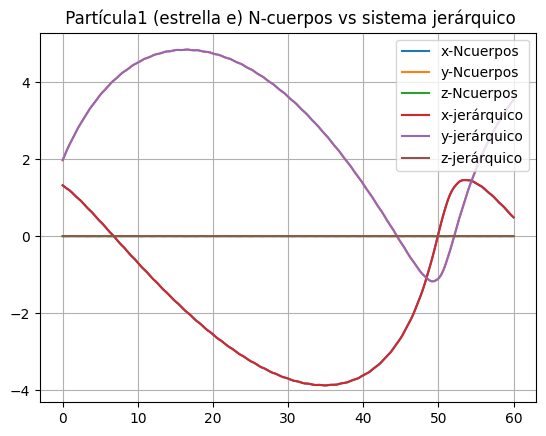

In [ ]:

plt.title(" Partícula1 (estrella e) N-cuerpos vs sistema jerárquico")

plt.plot(ts,rs[1,:,0],label="x-Ncuerpos")
plt.plot(ts,rs[1,:,1],label="y-Ncuerpos")
plt.plot(ts,rs[1,:,2],label="z-Ncuerpos")

plt.plot(ts,r1_t[:,0],label="x-jerárquico")
plt.plot(ts,r1_t[:,1],label="y-jerárquico")
plt.plot(ts,r1_t[:,2],label="z-jerárquico")

plt.grid()
plt.legend()

In [ ]:
#### Diferencia entre métodos Para la partícula 1



#valor esperado (la solución numérica)
Val_real = rs[1,:,0].mean() + rs[1,:,1].mean() + rs[1,:,2].mean()

#Valor medido (solución jerárquica)
Val_med = r1_t[:,0].mean() + r1_t[:,1].mean() + r1_t[:,2].mean()


print(abs((Val_real - Val_med)/Val_real)*100,"%")

0.022044661398188885 %


- Partícula 2

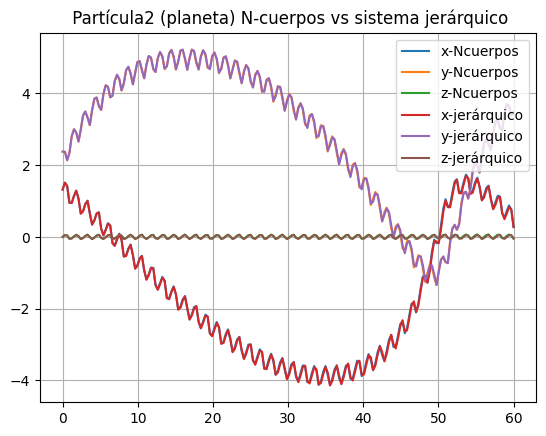

In [ ]:
plt.title(" Partícula2 (planeta) N-cuerpos vs sistema jerárquico")

plt.plot(ts,rs[2,:,0],label="x-Ncuerpos")
plt.plot(ts,rs[2,:,1],label="y-Ncuerpos")
plt.plot(ts,rs[2,:,2],label="z-Ncuerpos")

plt.plot(ts,r2_t[:,0],label="x-jerárquico")
plt.plot(ts,r2_t[:,1],label="y-jerárquico")
plt.plot(ts,r2_t[:,2],label="z-jerárquico")

plt.grid()
plt.legend()

In [ ]:
#### Diferencia entre métodos Para la partícula 2



#valor esperado (la solución numérica)
Val_real = rs[2,:,0].mean() + rs[2,:,1].mean() + rs[2,:,2].mean()

#Valor medido (solución jerárquica)
Val_med = r2_t[:,0].mean() + r2_t[:,1].mean() + r2_t[:,2].mean()


print(abs((Val_real - Val_med)/Val_real)*100,"%")

1.6942946006814654 %


- Partícula 3

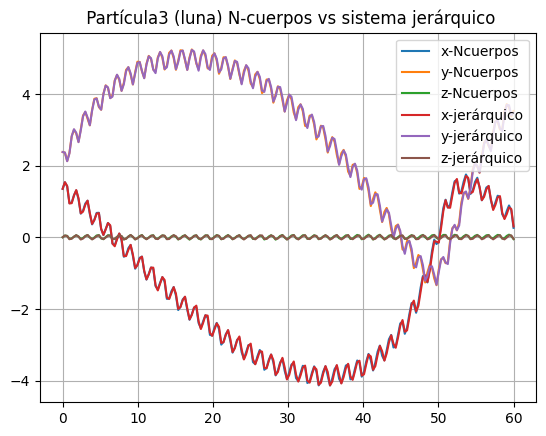

In [ ]:
plt.title(" Partícula3 (luna) N-cuerpos vs sistema jerárquico")

plt.plot(ts,rs[3,:,0],label="x-Ncuerpos")
plt.plot(ts,rs[3,:,1],label="y-Ncuerpos")
plt.plot(ts,rs[3,:,2],label="z-Ncuerpos")

plt.plot(ts,r3_t[:,0],label="x-jerárquico")
plt.plot(ts,r3_t[:,1],label="y-jerárquico")
plt.plot(ts,r3_t[:,2],label="z-jerárquico")

plt.grid()
plt.legend()

In [ ]:
#### Diferencia entre métodos Para la partícula 3



#valor esperado (la solución numérica)
Val_real = rs[3,:,0].mean() + rs[3,:,1].mean() + rs[3,:,2].mean()

#Valor medido (solución jerárquica)
Val_med = r3_t[:,0].mean() + r3_t[:,1].mean() + r3_t[:,2].mean()


print(abs((Val_real - Val_med)/Val_real)*100,"%")

0.8394690055242878 %


Obervamos que hay cierta diferencia pero en general esta no supera el 2%, las dos soluciones, la analítica (sistema jerárquico) y la numérica (ncuerpos_solución) son muy diferentes entre si pero llegan a resultados similares, teniendo en cuenta las grandes aproximaciones que se usan en el sistema jerárquico al tomar pares y no el sistema como un todo inicialmente, es valido concluir que este método funciona muy bien y es consistente.

#PUNTO 7

In [ ]:
##Constantes que nos será utiles para transformar las unidades canónicas

#Unidadad astronómica [m]
au = constants.au.value


#Constante de gravitación universal [m**3/(kg*s**2)]
G = constants.G.value

#Masa de jupiter [kg]
M_jup = constants.M_jup.value


###Transformamos las unidades canónicas a unidades del sistema internacional de unidades MKS

In [ ]:

Um = 80*M_jup

Ul = 0.01*au

Ut = np.sqrt(Ul**3/(G*Um))  ##Segundos


Ut_dias=Ut/86400   ##Días


###Ordenamos las masas, posiciones y velocidades de los cuerpos para que sea más fácil su manipulación en los ciclos para hallar las energías, además cambiamos sus unidades al sistema MKS

In [ ]:
masas = Um*np.array([m0,m1,m2,m3])

posiciones = Ul*np.array([r0_t,r1_t,r2_t,r3_t])

velocidades= (Ul/Ut)*np.array([vr0_t,vr1_t,vr2_t,vr3_t])

###Calculamos la energía cinética total en cada tiempo

In [ ]:

#lista principal, Ingresaremos las energías cinéticas totales en cada tiempo
E_cinetica=[]


#este ciclo me recorrerá los tiempos
for i in range(0,200):


  E_k=0


  #Este ciclo me recorrerá los 4 cuerpos del sistema
  for j in range(0,4):

    #Cálculo de la energía cinética total en cada tiempo
    E_k = E_k + masas[j]*np.dot(velocidades[j][i],velocidades[j][i])


  #Ingresamos cada energía cinética total en cada tiempo a la lista principal
  E_cinetica.append(0.5*E_k)



###$masas[j]$ me recorre cada masa, siendo $masas[0]$ corresponde a la masa de la partícula $0$, $masas[1]$ corresponde a la masa de la partícula 1 y así sucesivamente.

###$velocidades[j][i]$ me recorre las velocidades de cada cuerpo, el $[j]$ me indica el cuerpo, varia de 0 hasta 3, y $[i]$ me indica el tiempo que para nuestro ejercicio tenemos 200 datos.


###_----------------------------------------------------------------------------------------------------
##- Calcularemos la Energía potencial total en cada tiempo

###La expresión de la energía potencial es una interacción directa entre cada una de los cuerpos, en este caso se dejará un cuerpo fijo y mediremos cada una de sus interacciones con los demás planetas, haremos esto para cada cuerpo pero sin repetir las energías, ya que por ejemplo U12 es igual a U21, esto se restringe con el j>i, que en el ciclo lo veremos como $for \ j \ in \ range(i+1,4):$

In [ ]:

#lista principal, Ingresaremos las energías potenciales totales en cada tiempo
E_potencial = []


#este ciclo me recorrerá los tiempos
for k in range(0,200):


  E_pot_aux = 0

  #Este ciclo me recorrerá los 4 cuerpos del sistema
  for i in range(0,4):

    #Este ciclo me recorrera las interraciones de un cuerpo con los demás
    for j in range(i+1,4):

      #Calculamos la energía potencial
      E_pot = -masas[i]*G*masas[j]/(np.linalg.norm(posiciones[i][k]-posiciones[j][k]))


      #suma de las energías potenciales de para hallar la energía potencial de todo el sistema
      E_pot_aux = E_pot + E_pot_aux

  E_potencial.append(E_pot_aux)

Expresión para calcular la energía potencial total en cada tiempo

$
U_{total} = - \sum_{i<j} \sum_{i \neq j} \frac{m_{i} \mu{j}}{r_{ij}}
$

En el código tenemos la siguiente expresión para la energía potencial

$-masas[i]*G*masas[j]/(np.linalg.norm(posiciones[i][k]-posiciones[j][k]))$




- $masas[i]$ me recorre la masa de cada cuerpo, esta es equivalente a $m_{i}$    
- $G*masas[j]$me recorre cada masa con la que interacciona la  masa $m_{i}$, es equivalente a $\mu_{j}$
- $np.linalg.norm(posiciones[i][k]−posiciones[j][k])$ es la norma de las posiciones relativas entre $i$ y $j$.   $\ \ \ i$ será el cuerpo que dejamos fijo, y luego varía $j$ para ver las interacciones con los demás cuerpos, $k$ me varía los tiempos. Es equivalente a $r_{ij}$

In [ ]:
##Cálculamos la energía mecánica total

E_total =np.array(E_cinetica)+np.array(E_potencial)

Text(0.5, 0.98, 'Energías')

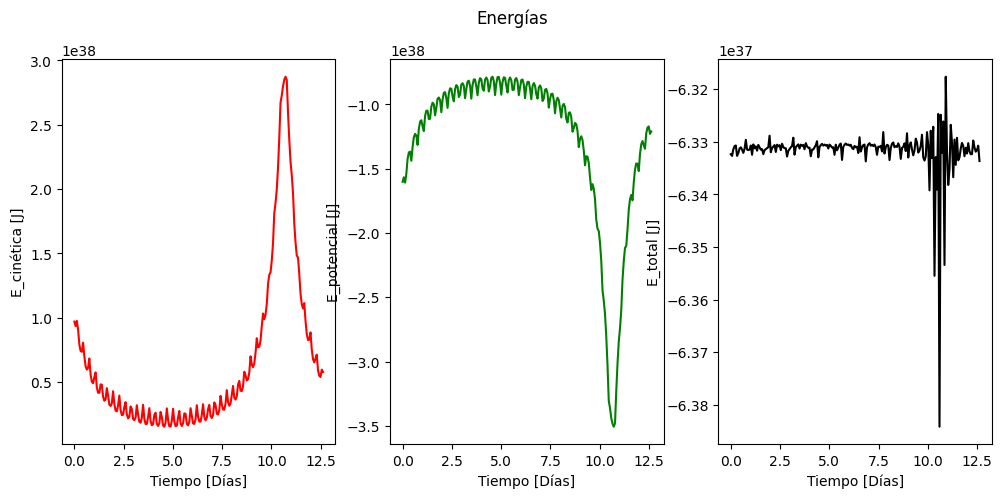

In [ ]:
##Grafico Energía

#Cambiamos las unidades canónicas a días
ts=np.linspace(0,60*Ut_dias,200)


plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.plot(ts,np.array(E_cinetica), "r") ##Energías cinéticas
plt.xlabel("Tiempo [Días]")
plt.ylabel("E_cinética [J]")

plt.subplot(1,3,2)
plt.plot(ts,np.array(E_potencial),"g") ##Energías potenciales
plt.xlabel("Tiempo [Días]")
plt.ylabel("E_potencial [J]")


plt.subplot(1,3,3)
plt.plot(ts,np.array(E_total),"k") ##cuadratura
plt.xlabel("Tiempo [Días]")
plt.ylabel("E_total [J]")
plt.suptitle("Energías")

#### Se observa como las energías cinéticas y potenciales son consistentes, lo cual nos permite encontrarnos con que la energía mecaníca total varía dentro de un rango muy pequeño, y como esto es una aproximación a la cuadratura de la energía para n-cuerpos, vemos como es relativamente constante también, esto confirma aún más que el cálculo analítico realizado por pares de cuerpos en un sistema jerárquico es una muy buena aproximación al problema real.